In [22]:
import pandas as pd


from utils.participant_data import load_participant
from utils.catchtrials import CatchTrials
from utils.gazedata import GazeData

In [23]:
participant_nr = "00"

DATA_ROOT = "data"
PARTICIPANT_FOLDER_PATTERN = f"participant_{participant_nr}"

df_pos = pd.read_csv("data/sentence_position.csv")

In [24]:
from utils.pres_mapper import PresentationMapper

mapper = PresentationMapper(
    real_order_path="data/sentences.js",
    exp_order_path=f"{DATA_ROOT}/{PARTICIPANT_FOLDER_PATTERN}/sentence_order_{participant_nr}.csv",
)

df_pos_mapped = df_pos.copy()
df_pos_mapped["presentation_index"] = df_pos_mapped["real_index"].map(
    mapper.get_real_to_pres_map()
)

assert df_pos_mapped["presentation_index"].notna().all()


[PresentationMapper] Initialising...
  real_order_path : data/sentences.js
  exp_order_path  : data/participant_00/sentence_order_00.csv
  Loaded 97 sentences from real_order
  First sentence : "Il est 4 heures du matin et John est sur le point de s'endormir lorsqu'il entend des coups de feu."
  Last sentence  : "Magnus doit rejoindre son ami pour prendre un café, il décide de regarder l'heure sur son portable."
  exp_order shape : (97, 4)
  exp_order columns : ['real_index', 'presentation_index', 'first', 'second']
  Mapping complete. Sample rows:
 presentation_index                                                                                                                                                                                                                                     first  real_index
                  0                                                                                       Sam se fait réveiller par l'aboiement de son chien en pleine nuit. Il se

In [25]:
df_pos_mapped.head()

,real_index,part_nr,line_idx,text,top,bottom,left,right,presentation_index
0,0,1,0,Il est 4 heures du matin et John est sur le po...,323,368,137,1775,79
1,0,1,1,lorsqu'il entend des coups de feu.,411,456,514,1398,79
2,0,2,0,Il sursaute de son lit et regarde par sa fenêtre.,579,624,319,1593,79
3,1,1,0,Il est 4 heures du matin et Mike s'apprête à a...,191,236,215,1697,84
4,1,1,1,lorsque soudain il entend un homme crier 'Adie...,279,324,176,1736,84


# Catch trials analysis

In [26]:

p = load_participant(participant_nr)   # or whatever participant_nr you're on

p.calibration        # dict from the JSON
p.catch_trials        # DataFrame
p.experiment           # DataFrame
p.gaze                 # DataFrame
p.sentence_order       # DataFrame

CatchTrials.from_dataframe(p.catch_trials).summary()  # reuse your existing analysis on just this one

Total trials     : 10
Unique sentences : 9
Percent correct  : 90.0%
Mean RT          : 4212.5 ms

RT by correctness:
           count     min      q1  median      q3     max
response                                                
incorrect    1.0  5296.0  5296.0  5296.0  5296.0  5296.0
correct      9.0  1776.0  2976.0  3904.0  4032.0  8303.0
Catch types      : 
catch_type
seen      6
unseen    4
Name: count, dtype: int64


# Gaze analysis

In [27]:
print(f"Shape: {p.gaze.shape}")
print(f"\nColumns: {list(p.gaze.columns)}")
print(f"\nDtypes:\n{p.gaze.dtypes}")

Shape: (55175, 1)

Columns: ['CNT\tTIME\tTIME_TICK\tFPOGX\tFPOGY\tFPOGS\tFPOGD\tFPOGID\tFPOGV\tLPOGX\tLPOGY\tLPOGV\tRPOGX\tRPOGY\tRPOGV\tBPOGX\tBPOGY\tBPOGV\tLPCX\tLPCY\tLPD\tLPS\tLPV\tRPCX\tRPCY\tRPD\tRPS\tRPV\tLEYEX\tLEYEY\tLEYEZ\tLPUPILD\tLPUPILV\tREYEX\tREYEY\tREYEZ\tRPUPILD\tRPUPILV\tCX\tCY\tCS\tUSER']

Dtypes:
CNT\tTIME\tTIME_TICK\tFPOGX\tFPOGY\tFPOGS\tFPOGD\tFPOGID\tFPOGV\tLPOGX\tLPOGY\tLPOGV\tRPOGX\tRPOGY\tRPOGV\tBPOGX\tBPOGY\tBPOGV\tLPCX\tLPCY\tLPD\tLPS\tLPV\tRPCX\tRPCY\tRPD\tRPS\tRPV\tLEYEX\tLEYEY\tLEYEZ\tLPUPILD\tLPUPILV\tREYEX\tREYEY\tREYEZ\tRPUPILD\tRPUPILV\tCX\tCY\tCS\tUSER    str
dtype: object


In [28]:
path = f"{DATA_ROOT}/{PARTICIPANT_FOLDER_PATTERN}/gaze_{participant_nr}.csv"

gaze = GazeData(path)


## simple statistics

In [29]:
print("Fixation Statistics:")
print(gaze.fixation_stats())
print("\nPupil Statistics:")
print(gaze.pupil_stats())

Fixation Statistics:
n_fixations        2106.00
mean_duration         0.25
median_duration       0.20
mean_x                0.49
mean_y                0.46
dtype: float64

Pupil Statistics:
             left     right
mean        15.78     15.47
median      15.51     15.21
n_valid  45912.00  46100.00


In [30]:
gaze.summary()

Total samples    : 55175
Duration         : 10497.49 s
Valid fixations  : 37283
User events      : 55175

Fixation stats:
n_fixations        2106.00
mean_duration         0.25
median_duration       0.20
mean_x                0.49
mean_y                0.46
dtype: float64

Pupil stats:
             left     right
mean        15.78     15.47
median      15.51     15.21
n_valid  45912.00  46100.00


In [31]:
print("sentence duration")
gaze.sentence_duration_stats()

sentence duration


mean       3.46
median     2.77
min        0.00
max       15.88
std        2.81
dtype: float64

## gaze eda / stats

[pres 76] total gaze: 38 | before part 2: 0 | from part 2 start onward: 38


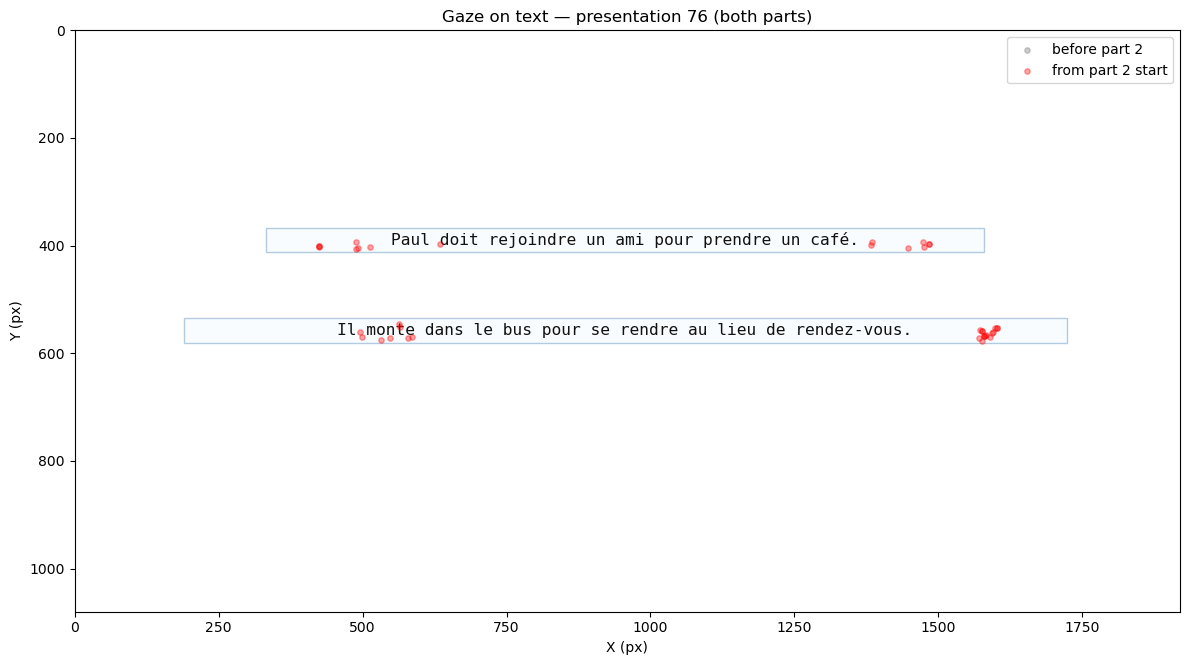

1.0
saccade_type
line_regression           1
within_line_regression    1
Name: count, dtype: int64


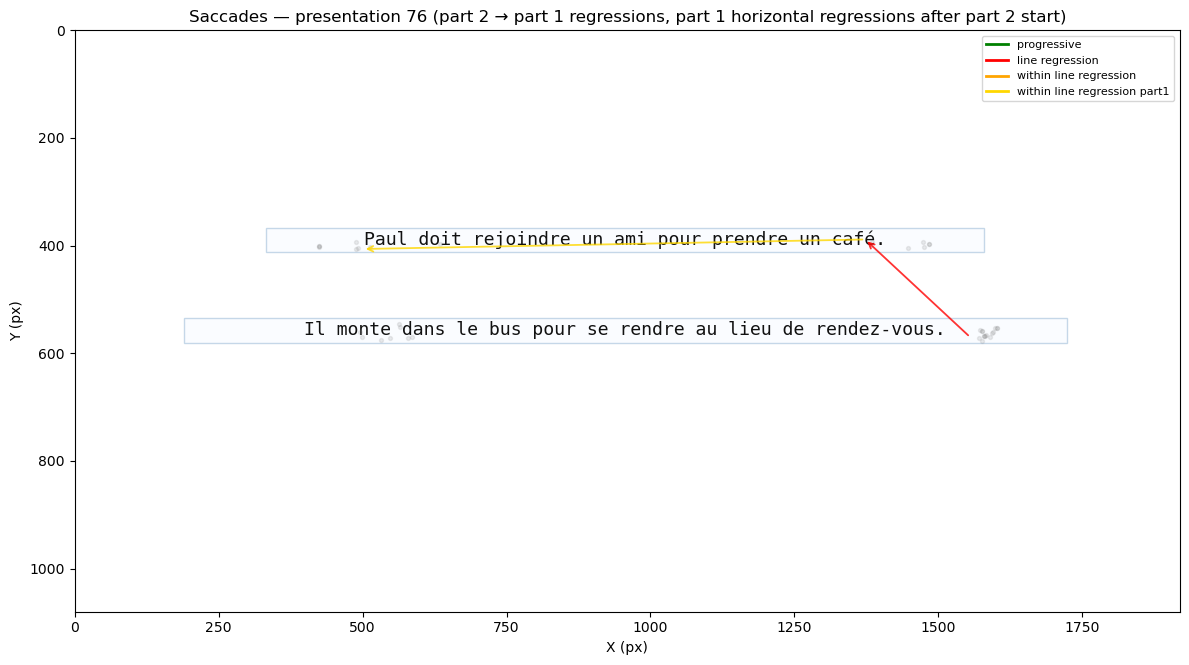

In [32]:
presentation = 76

results = gaze.gaze_on_screen(df_pos_mapped)

gaze.plot_gaze_on_text(df_pos_mapped, pres=presentation, results=results)

sacc = gaze.saccades_movement(pres=presentation, df_position=df_pos_mapped)
print(sacc["is_regression"].mean())
print(sacc["saccade_type"].value_counts())

gaze.plot_saccades_on_text(
    df_pos_mapped,
    pres=presentation,
    saccades=sacc,
    show_gaze=True,
    results=results,
)

In [33]:
stats = gaze.gaze_fix_stats(df_pos_mapped)

In [34]:
stats[stats["fixations"] == 1]

,presentation,gaze_samples,fixations,horizontal_fixations
13,13,57,1,0
23,23,7,1,0
26,26,46,1,0
30,30,151,1,1
49,49,105,1,0
53,53,15,1,0
59,59,95,1,1
67,67,36,1,0
71,71,11,1,0
76,76,15,1,1


### analysis / plots

In [39]:
def add_conditions(stats, df_pos_mapped, conditions_df):
    """Attach real_index + condition labels to gaze_fix_stats output."""
    pres_to_real = (
        df_pos_mapped[["presentation_index", "real_index"]]
        .drop_duplicates()
        .rename(columns={"presentation_index": "presentation"})
    )
    df = stats.merge(pres_to_real, on="presentation", how="left")
    df = df.merge(
        conditions_df[["real_index", "groupVal", "groupUnc", "groupRes"]],
        on="real_index", how="left"
    )
    missing = df["groupVal"].isna().sum()
    if missing:
        print(f"WARNING: {missing} presentations had no condition match")
    return df.dropna(subset=["groupVal", "groupUnc", "groupRes"])

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_total_fixations_by_condition(df, metric="fixations", ylabel="Total fixations"):
    """Bar chart of SUMMED fixation counts per condition (Valence x Resolution x Uncertainty),
    all bars on the same y-scale for direct comparison."""
    val_order = sorted(df["groupVal"].unique())
    unc_order = sorted(df["groupUnc"].unique())
    res_order = sorted(df["groupRes"].unique())
    x = np.arange(len(res_order))
    bar_width = 0.35

    palette = cm.get_cmap("tab10", max(len(unc_order), 1))
    colors = {unc: palette(i) for i, unc in enumerate(unc_order)}

    totals = df.groupby(["groupVal", "groupUnc", "groupRes"])[metric].sum().reset_index()
    ymax = totals[metric].max() * 1.05 if len(totals) else 1

    fig, axes = plt.subplots(1, len(val_order), figsize=(5 * len(val_order), 5), sharey=True)
    if len(val_order) == 1:
        axes = [axes]

    for col, val in enumerate(val_order):
        ax = axes[col]
        sub = totals[totals["groupVal"] == val]

        for i, unc in enumerate(unc_order):
            rows = sub[sub["groupUnc"] == unc].set_index("groupRes").reindex(res_order)
            offset = (i - 0.5) * bar_width
            ax.bar(
                x + offset, rows[metric].fillna(0), bar_width,
                color=colors[unc],
                label=unc if col == 0 else None,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(res_order)
        ax.set_ylim(0, ymax)
        ax.set_title(f"Valence: {val}")
        ax.set_xlabel("Resolution")
        if col == 0:
            ax.set_ylabel(ylabel)

    fig.legend(*axes[0].get_legend_handles_labels(), title="Uncertainty",
               loc="upper right", bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f"{ylabel} across conditions", fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig

C:\Users\blanc\AppData\Local\Temp\ipykernel_15276\706119335.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))
C:\Users\blanc\AppData\Local\Temp\ipykernel_15276\706119335.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", max(len(unc_order), 1))


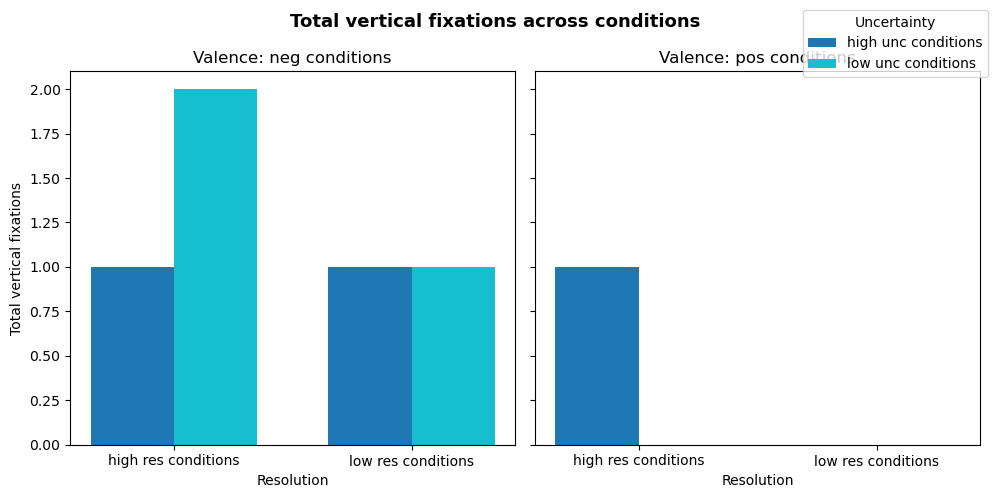

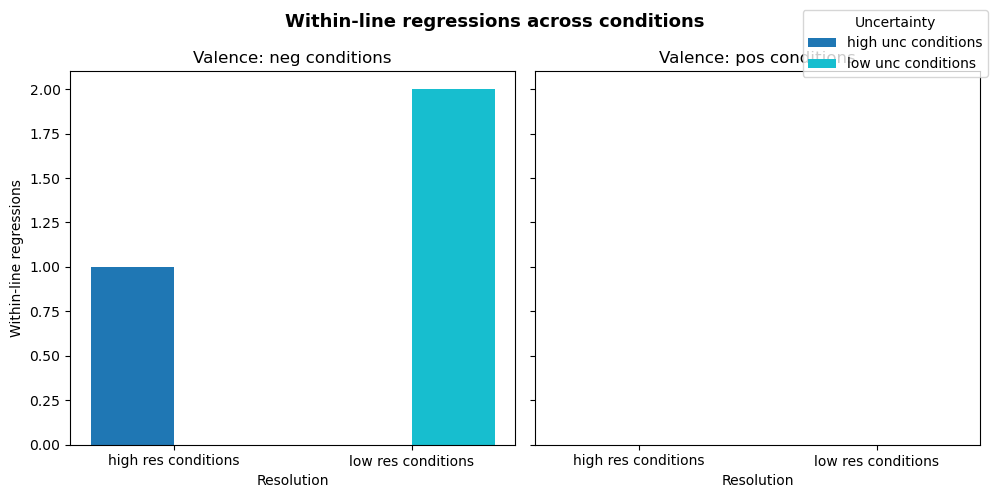

In [45]:
conditions_df = pd.read_excel(
    "data/combined_valid_sentences.xlsx"
)

conditions_df = conditions_df.rename(columns={conditions_df.columns[0]: "real_index"})

stats = gaze.gaze_fix_stats(df_pos_mapped)
df = add_conditions(stats, df_pos_mapped, conditions_df)

plot_total_fixations_by_condition(df, metric="fixations", ylabel="Total vertical fixations")
plot_total_fixations_by_condition(df, metric="horizontal_fixations", ylabel="Within-line regressions")
plt.show()
plt.show()
